# Настройка окружения

In [ ]:
%%capture
!pip install -q chembl_webresource_client
!pip install -q torch_geometric
!pip install -q chembl_structure_pipeline
!pip install -q rdkit moses tqdm pandas numpy matplotlib

In [ ]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, DataStructs
from rdkit.Chem import QED as rdQED
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display
from PIL import Image as PILImage
import io
from rdkit.Chem.rdMolDescriptors import CalcTPSA
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
import sys, urllib.request
import warnings
warnings.filterwarnings('ignore')

In [ ]:
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py',
    '/tmp/sascorer.py')
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz',
    '/tmp/fpscores.pkl.gz')

sys.path.insert(0, '/tmp')
import sascorer
print('SA Score загружен')

SA Score загружен


# Загрузка данных

In [ ]:
df = pd.read_csv('/content/generated_valid_molecules_ENCORAFENIB.csv')

# Приводим колонку smiles к единому виду
df = df.rename(columns={'smiles': 'SMILES'})
df['mol'] = df['SMILES'].apply(Chem.MolFromSmiles)
df = df[df['mol'].notna()].reset_index(drop=True)
print(f"Загружено молекул: {len(df)}")
df.head(3)

Загружено молекул: 22


,temperature,SMILES,similarity_to_ENCORAFENIB,qed,mw,logp,mol
0,1.1,COC(=O)N[C@@H](C)CNc1nccc(-c2cn(C(C)C)nc2C(=O)...,0.983238,0.211618,546.437,5.70840,<rdkit.Chem.rdchem.Mol object at 0x7d395e9aaab0>
1,1.1,COC(=O)N[C@@H](C)CNc1nccc(-c2cn(C(C)C)nc2CC(F)...,0.981833,0.469363,507.561,4.88064,<rdkit.Chem.rdchem.Mol object at 0x7d395e9aaf10>
2,1.1,COC(=O)N[C@@H](C)CNc1nccc(-c2cn(C(C)C)nc2C(C)(...,0.981080,0.804970,374.489,3.37490,<rdkit.Chem.rdchem.Mol object at 0x7d395e9aaf80>


# Биологическая активность

Мишень - Serine/threonine-protein kinase B-raf (CHEMBL5145) меланома

Пороговое значение: IC50 ≤ 1000 нM (pIC50 ≥ 6), следовательно класс активный

In [ ]:
chembl_df = pd.read_csv('/content/chembl.csv')

In [ ]:
chembl_df['pIC50'] = -np.log10(chembl_df['standard_value'] * 1e-9)

chembl_df = chembl_df.groupby('canonical_smiles', as_index=False).agg(pIC50=('pIC50', 'median'))
chembl_df['mol'] = chembl_df['canonical_smiles'].apply(Chem.MolFromSmiles)
chembl_df = chembl_df[chembl_df['mol'].notna()].reset_index(drop=True)

chembl_df['active'] = (chembl_df['pIC50'] >= 6.0).astype(int)

n_active   = chembl_df['active'].sum()
n_inactive = (chembl_df['active'] == 0).sum()
print(f"Итого молекул: {len(chembl_df)}")
print(f"Активных: {n_active} ({n_active/len(chembl_df)*100:.1f}%)")
print(f"Неактивных: {n_inactive} ({n_inactive/len(chembl_df)*100:.1f}%)")

Итого молекул: 6071
Активных: 5310 (87.5%)
Неактивных: 761 (12.5%)


Morgan FP (1024 бит) + 9 физико-химических дескрипторов: MW, LogP, PSA, HBD, HBA, nRotB, nAr, Fsp3, QED

In [ ]:
# Генератор Morgan fingerprints - основа для ML
_morgan_gen = GetMorganGenerator(radius=2, fpSize=1024)

def compute_descriptors(mol):
    fp  = np.array(_morgan_gen.GetFingerprintAsNumPy(mol), dtype=np.float32)

    # Дескрипторы
    phc = np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        CalcTPSA(mol),
        rdMolDescriptors.CalcNumHBD(mol),
        rdMolDescriptors.CalcNumHBA(mol),
        rdMolDescriptors.CalcNumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        rdMolDescriptors.CalcFractionCSP3(mol),
        rdQED.qed(mol),
    ], dtype=np.float32)
    return np.concatenate([fp, phc])

X_chembl = np.vstack([compute_descriptors(m) for m in chembl_df['mol']])
y_chembl = chembl_df['active'].values
X_gen = np.vstack([compute_descriptors(m) for m in df['mol']])

print(f"ChEMBL матрица: {X_chembl.shape}")
print(f"Аналоги энкорафениба: {X_gen.shape}")

ChEMBL матрица: (6071, 1033)
Аналоги энкорафениба: (22, 1033)


In [ ]:
# Разделение ChEMBL на train, val, test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_chembl, y_chembl,
    test_size=0.20, stratify=y_chembl, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25, stratify=y_train_full, random_state=42
)

print(f"Train: {X_train.shape[0]:>5} ({y_train.mean()*100:.1f}% активных)")
print(f"Val: {X_val.shape[0]:>5} ({y_val.mean()*100:.1f}% активных)")
print(f"Test: {X_test.shape[0]:>5} ({y_test.mean()*100:.1f}% активных)")
print(f"Train_full: {X_train_full.shape[0]:>5}  ({y_train_full.mean()*100:.1f}% активных)")
print(f"Итого: {X_chembl.shape[0]:>5}")

Train:  3642 (87.5% активных)
Val:  1214 (87.5% активных)
Test:  1215 (87.5% активных)
Train_full:  4856  (87.5% активных)
Итого:  6071


Проверка scaffold leakage

Scaffold leakage возникает, когда сгенерированные молекулы структурно похожи на молекулы из тренировочного набора. В этом случае модель предсказывает их активность не потому что они реально активны,
а потому что видела похожий скаффолд при обучении

Проверяем через Nearest Neighbour Tanimoto Similarity (NNS): для каждой сгенерированной молекулы
находим максимальное сходство с любой молекулой из  тренировочного набора.
Если медианный NNS < 0.4 - проблемы leakage практически нет

In [ ]:
# Morgan FP для подсчета Tanimoto
_morgan_gen_2048 = GetMorganGenerator(radius=2, fpSize=2048)

def get_morgan_fp(mol):
    return _morgan_gen_2048.GetFingerprint(mol)

# FP для молекул из train
idx_train_full = np.arange(len(y_chembl))
idx_tf, idx_test_arr = train_test_split(idx_train_full, test_size=0.20,
                                         stratify=y_chembl, random_state=42)
idx_tr, idx_val_arr  = train_test_split(idx_tf, test_size=0.25,
                                         stratify=y_chembl[idx_tf], random_state=42)

train_fps = [get_morgan_fp(chembl_df['mol'].iloc[i]) for i in idx_tr]
gen_fps = [get_morgan_fp(m) for m in df['mol']]

In [ ]:
# Считаем NNS сгенерированных молекул к train-набору
nns_scores = []
for fp in gen_fps:
    sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
    nns_scores.append(max(sims))

df['NNS_to_train'] = nns_scores

print(f"Медиана: {np.median(nns_scores):.3f}")
print(f"Среднее: {np.mean(nns_scores):.3f}")
print(f"% молекул с NNS > 0.7: {(np.array(nns_scores) > 0.7).mean()*100:.1f}%")

Медиана: 0.554
Среднее: 0.557
% молекул с NNS > 0.7: 0.0%


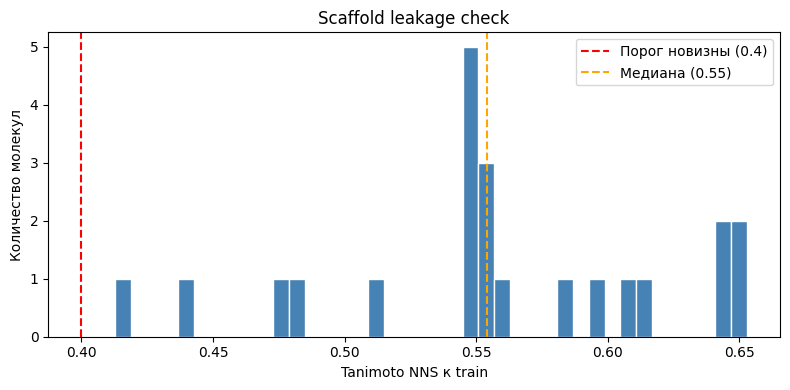

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(nns_scores, bins=40, color='steelblue', edgecolor='white')
plt.axvline(0.4, color='red', linestyle='--', label='Порог новизны (0.4)')
plt.axvline(np.median(nns_scores), color='orange', linestyle='--',
            label=f'Медиана ({np.median(nns_scores):.2f})')
plt.xlabel('Tanimoto NNS к train')
plt.ylabel('Количество молекул')
plt.title('Scaffold leakage check')
plt.legend()
plt.tight_layout()
plt.show()

Большинство молекул в выборке имеют сходство с обучающим набором вокруг значения 0.55, и ни одна молекула не имеет сходства ниже порога новизны 0.4

Обучение QSAR-моделей

Random Forest + Gradient Boosting (метрика ROC-AUC + PR-AUC)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2,
    class_weight="balanced", random_state=42, n_jobs=-1
)
gb_model = GradientBoostingClassifier(
    n_estimators= 200, learning_rate=0.05,
    max_depth=4, subsample=0.8, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# Кросс-валидация
print("Кросс-валидация на train-наборе:")
for name, model in [('Random Forest', rf_model), ('Gradient Boosting', gb_model)]:
    roc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    pr = cross_val_score(model, X_train, y_train, cv=cv, scoring='average_precision', n_jobs=-1)

    model.fit(X_train, y_train)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    roc_val = roc_auc_score(y_val, y_val_proba)
    pr_val  = average_precision_score(y_val, y_val_proba)

    print(f"{name}")
    print(f"CV ROC-AUC: {roc.mean():.3f} ± {roc.std():.3f}")
    print(f"CV PR-AUC: {pr.mean():.3f} ± {pr.std():.3f}")
    print(f"ROC-AUC: {roc_val:.3f}")
    print(f"PR-AUC: {pr_val:.3f}")

Кросс-валидация на train-наборе:
Random Forest
CV ROC-AUC: 0.945 ± 0.007
CV PR-AUC: 0.991 ± 0.001
ROC-AUC: 0.945
PR-AUC: 0.991
Gradient Boosting
CV ROC-AUC: 0.924 ± 0.017
CV PR-AUC: 0.984 ± 0.005
ROC-AUC: 0.902
PR-AUC: 0.981


In [ ]:
# Финальное обучение на train + val
rf_model.fit(X_train_full, y_train_full)
gb_model.fit(X_train_full, y_train_full)

GradientBoostingClassifier(learning_rate=0.05, max_depth=4, n_estimators=200,
                           random_state=42, subsample=0.8)

In [ ]:
print("Метрики на TEST-наборе")

for name, model in [('Random Forest', rf_model), ('Gradient Boosting', gb_model)]:
    y_test_proba = model.predict_proba(X_test)[:, 1]
    y_test_pred  = (y_test_proba >= 0.5).astype(int)
    roc_test = roc_auc_score(y_test, y_test_proba)
    pr_test  = average_precision_score(y_test, y_test_proba)

    print(f"{name}")
    print(f"  Test ROC-AUC: {roc_test:.3f}")
    print(f"  Test PR-AUC:  {pr_test:.3f}")
    print(classification_report(y_test, y_test_pred,
                                target_names=['Inactive', 'Active'], digits=3))

Метрики на TEST-наборе
Random Forest
  Test ROC-AUC: 0.951
  Test PR-AUC:  0.992
              precision    recall  f1-score   support

    Inactive      0.726     0.750     0.738       152
      Active      0.964     0.960     0.962      1063

    accuracy                          0.933      1215
   macro avg      0.845     0.855     0.850      1215
weighted avg      0.934     0.933     0.934      1215

Gradient Boosting
  Test ROC-AUC: 0.931
  Test PR-AUC:  0.985
              precision    recall  f1-score   support

    Inactive      0.808     0.553     0.656       152
      Active      0.939     0.981     0.960      1063

    accuracy                          0.928      1215
   macro avg      0.873     0.767     0.808      1215
weighted avg      0.922     0.928     0.922      1215



Для фильтрации сгенерированных аналогов энкорафениба была обучена QSAR-модель на данных ChEMBL (мишень CHEMBL5145)

Из двух моделей (Random Forest и Gradient Boosting) лучшие результаты на независимом тесте показал Random Forest: ROC-AUC = 0.951, PR-AUC = 0.992, F1 = 0.962 на активном классе. Gradient Boosting демонстрирует сопоставимый ROC-AUC (0.931), но он хуже распознает неактивные молекулы (recall = 0.553)

Дополнительно проведена проверка scaffold leakage: медианное Tanimoto-сходство сгенерированных молекул с тренировочным набором составило 0.554, молекул с NNS > 0.7 не обнаружено

Предсказание активности

In [ ]:
df['p_active_RF'] = rf_model.predict_proba(X_gen)[:, 1]
df['p_active_GB'] = gb_model.predict_proba(X_gen)[:, 1]
df['p_active_mean'] = (df['p_active_RF'] + df['p_active_GB']) / 2

print("Проверка стандартного порога (0.5)")

strict_threshold = 0.5
strict_mask = (df['p_active_RF'] >= strict_threshold) & (df['p_active_GB'] >= strict_threshold)
n_strict = strict_mask.sum()

print(f"Стандартный порог (≥ {strict_threshold}): {n_strict} из {len(df)} молекул")

Проверка стандартного порога (0.5)
Стандартный порог (≥ 0.5): 22 из 22 молекул


In [ ]:
active_df = df.copy()
active_df = df[strict_mask].reset_index(drop=True)

print("Молекулы после ML-фильтра")
print(f"Итого молекул: {len(active_df)} из {len(df)}")
print(f"Сохранено: {len(active_df) / len(df) * 100:.1f}%")

Молекулы после ML-фильтра
Итого молекул: 22 из 22
Сохранено: 100.0%


# drug-likeness

In [ ]:
def add_physchem(df_in):
    rows = []
    for mol in df_in['mol']:
        rows.append({
            'MW':       round(Descriptors.MolWt(mol), 1),
            'LogP':     round(Descriptors.MolLogP(mol), 2),
            'PSA':      round(CalcTPSA(mol), 1),
            'HBD':      rdMolDescriptors.CalcNumHBD(mol),
            'HBA':      rdMolDescriptors.CalcNumHBA(mol),
            'nRotB':    rdMolDescriptors.CalcNumRotatableBonds(mol),
            'nAr':      rdMolDescriptors.CalcNumAromaticRings(mol),
            'Fsp3':     round(rdMolDescriptors.CalcFractionCSP3(mol), 3),
            'QED':      round(rdQED.qed(mol), 3),
            'SA_score': round(sascorer.calculateScore(mol), 2),
        })
    return pd.concat([df_in.reset_index(drop=True), pd.DataFrame(rows)], axis=1)

df_filtered = add_physchem(active_df)
print(f"Молекул для анализа: {len(df_filtered)}")

Молекул для анализа: 22


Правило Липински

In [ ]:
def lipinski_violations(row):
    v = 0
    if row['MW']   > 500: v += 1
    if row['LogP'] > 5:   v += 1
    if row['HBD']  > 5:   v += 1
    if row['HBA']  > 10:  v += 1
    return v

df_filtered['Ro5_violations'] = df_filtered.apply(lipinski_violations, axis=1)

n_before = len(df_filtered)
df_filtered = df_filtered[df_filtered['Ro5_violations'] <= 1].reset_index(drop=True)
print(f"Правило Липински - удалено: {n_before - len(df_filtered)}, осталось: {len(df_filtered)}")

Правило Липински - удалено: 4, осталось: 18


Синтетическая доступность

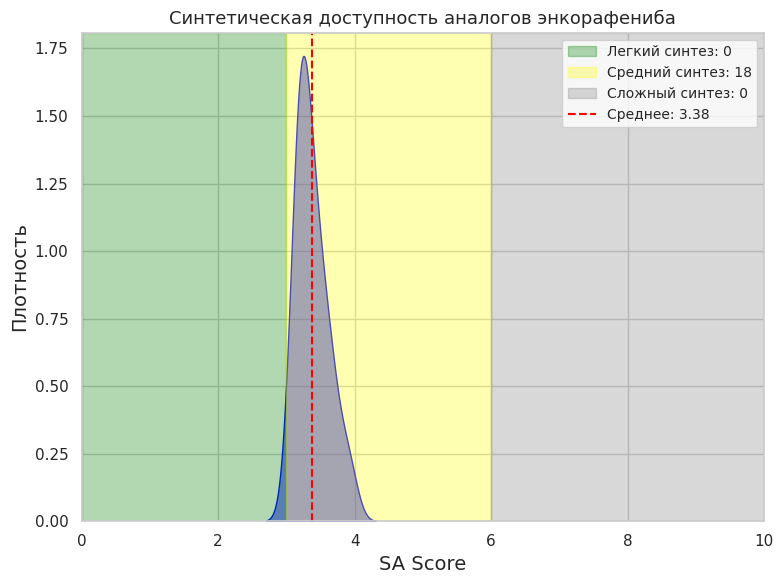

In [ ]:
easy = (df_filtered['SA_score'] < 3).sum()
medium = ((df_filtered['SA_score'] >= 3) & (df_filtered['SA_score'] <= 6)).sum()
hard = (df_filtered['SA_score'] > 6).sum()
mean_sa = df_filtered['SA_score'].mean()

sns.set(style='whitegrid')
plt.figure(figsize=(8, 6))

sns.kdeplot(df_filtered['SA_score'], color='blue', fill=True, alpha=0.5)

plt.axvspan(0, 3, alpha=0.30, color='green', label=f'Легкий синтез: {easy}')
plt.axvspan(3, 6, alpha=0.30, color='yellow', label=f'Средний синтез: {medium}')
plt.axvspan(6, 10, alpha=0.30, color='grey', label=f'Сложный синтез: {hard}')
plt.axvline(mean_sa, color='red', linestyle='--', label=f'Среднее: {mean_sa:.2f}')

plt.xlabel('SA Score', fontsize=14)
plt.ylabel('Плотность', fontsize=14)
plt.title('Синтетическая доступность аналогов энкорафениба', fontsize=13)
plt.xlim(0, 10)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Все проанализированные аналоги энкорафениба имеют средний уровень сложности синтеза

In [ ]:
n_before = len(df_filtered)
df_filtered = df_filtered[df_filtered['SA_score'] <= 6].reset_index(drop=True)
print(f"Фильтр SA: удалено {n_before - len(df_filtered)}, осталось {len(df_filtered)}")

Фильтр SA: удалено 0, осталось 18


Полярная поверхностная площадь

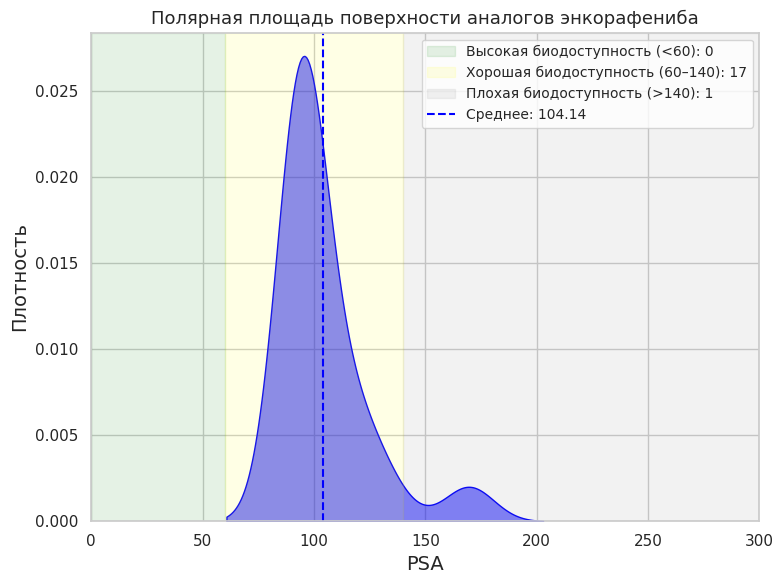

In [ ]:
psa_low  = (df_filtered['PSA'] < 60).sum()
psa_opt  = ((df_filtered['PSA'] >= 60) & (df_filtered['PSA'] <= 140)).sum()
psa_high = (df_filtered['PSA'] > 140).sum()
mean_psa = df_filtered['PSA'].mean()

plt.figure(figsize=(8, 6))

sns.kdeplot(df_filtered['PSA'], color='blue', fill=True, alpha=0.5)

plt.axvspan(0,   60,  alpha=0.10, color='green',  label=f'Высокая биодоступность (<60): {psa_low}')
plt.axvspan(60,  140, alpha=0.10, color='yellow', label=f'Хорошая биодоступность (60–140): {psa_opt}')
plt.axvspan(140, 300, alpha=0.10, color='grey',   label=f'Плохая биодоступность (>140): {psa_high}')
plt.axvline(mean_psa, color='blue', linestyle='--', label=f'Среднее: {mean_psa:.2f}')

plt.xlabel('PSA', fontsize=14)
plt.ylabel('Плотность', fontsize=14)
plt.title('Полярная площадь поверхности аналогов энкорафениба', fontsize=13)
plt.xlim(0, 300)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Большинство аналогов имеют полярную площадь поверхности в диапазоне, обеспечивающем хорошую биодоступность. Только одна молекула имеет слишком высокую PSA, что прогнозирует плохую биодоступность

In [ ]:
n_before = len(df_filtered)
df_filtered = df_filtered[df_filtered['PSA'] <= 140].reset_index(drop=True)
print(f"Фильтр PSA: удалено {n_before - len(df_filtered)}, осталось {len(df_filtered)}")

Фильтр PSA: удалено 1, осталось 17


# Токсичность

In [ ]:
def check_filter(mol, catalog_name):
    params = FilterCatalogParams()
    params.AddCatalog(getattr(FilterCatalogParams.FilterCatalogs, catalog_name))
    catalog = FilterCatalog(params)
    entry = catalog.GetFirstMatch(mol)
    return (True, entry.GetDescription()) if entry else (False, 'нет')

pains = df_filtered['mol'].apply(lambda m: check_filter(m, 'PAINS'))
df_filtered['PAINS_flag'] = pains.apply(lambda x: x[0])

brenk = df_filtered['mol'].apply(lambda m: check_filter(m, 'BRENK'))
df_filtered['Brenk_flag'] = brenk.apply(lambda x: x[0])

print(f"PAINS: {df_filtered['PAINS_flag'].sum()} молекул")
print(f"Brenk: {df_filtered['Brenk_flag'].sum()} молекул")

PAINS: 0 молекул
Brenk: 2 молекул


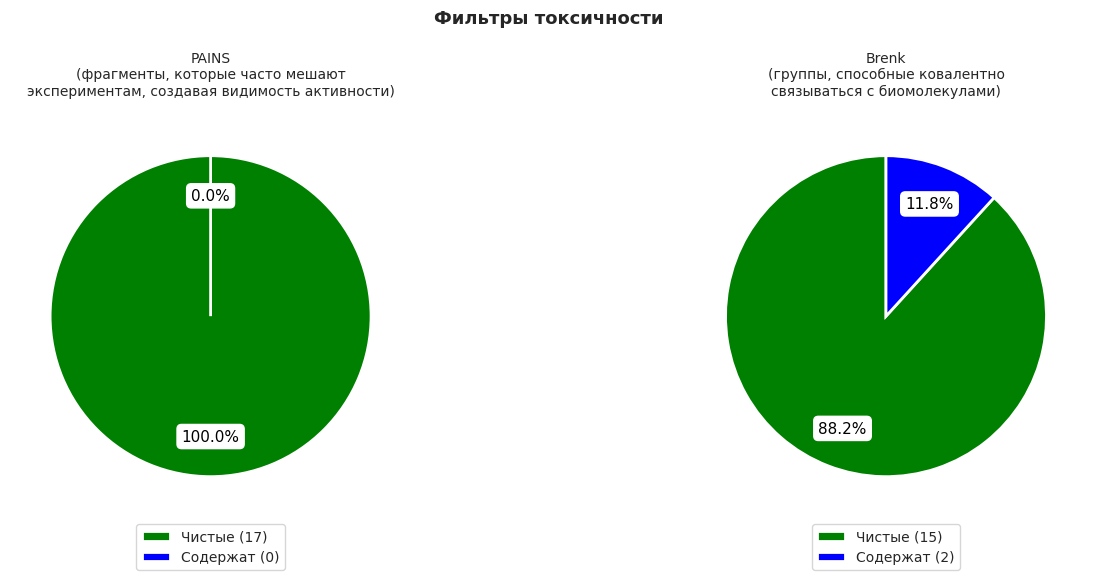

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Фильтры токсичности', fontsize=13, fontweight='bold')

for ax, (flag, title) in zip(axes, [
    ('PAINS_flag', 'PAINS\n(фрагменты, которые часто мешают\nэкспериментам, создавая видимость активности)'),
    ('Brenk_flag', 'Brenk\n(группы, способные ковалентно\nсвязываться с биомолекулами)'),
]):
    cnt_bad  = df_filtered[flag].sum()
    cnt_good = (~df_filtered[flag]).sum()

    wedges, texts, autotexts = ax.pie(
        [cnt_good, cnt_bad],
        colors=['green', 'blue'],
        autopct='%1.1f%%',
        pctdistance=0.75,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    )

    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontsize(11)
        autotext.set_bbox(dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor='white',
        ))

    ax.legend(
        wedges,
        [f'Чистые ({cnt_good})', f'Содержат ({cnt_bad})'],
        loc='lower center',
        bbox_to_anchor=(0.5, -0.15),
        fontsize=10
    )
    ax.set_title(title, fontsize=10, pad=15)

plt.tight_layout()
plt.show()

Из текущей выборки все прошли фильтр PAINS, но 2 молекулы не прошли фильтр Brenk

In [ ]:
n_before = len(df_filtered)
df_filtered = df_filtered[~df_filtered['PAINS_flag'] & ~df_filtered['Brenk_flag']].reset_index(drop=True)
print(f"Фильтры PAINS + Brenk: удалено {n_before - len(df_filtered)}, осталось {len(df_filtered)}")

Фильтры PAINS + Brenk: удалено 2, осталось 15


### QED

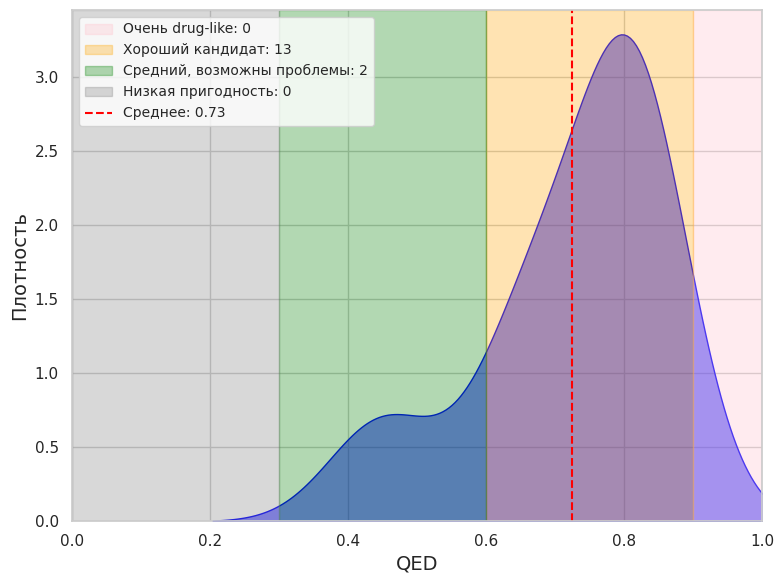

In [ ]:
qed_very_good = (df_filtered['QED'] >= 0.9).sum()
qed_good = ((df_filtered['QED'] >= 0.6) & (df_filtered['QED'] < 0.9)).sum()
qed_mid = ((df_filtered['QED'] >= 0.3) & (df_filtered['QED'] < 0.6)).sum()
qed_low = (df_filtered['QED'] < 0.3).sum()
mean_qed = df_filtered['QED'].mean()

sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))

sns.kdeplot(df_filtered['QED'], color='blue', fill=True, alpha=0.5)

plt.axvspan(0.9, 1.0, alpha=0.3, color='pink', label=f'Очень drug-like: {qed_very_good}')
plt.axvspan(0.6, 0.9, alpha=0.3, color='orange', label=f'Хороший кандидат: {qed_good}')
plt.axvspan(0.3, 0.6, alpha=0.3, color='green', label=f'Средний, возможны проблемы: {qed_mid}')
plt.axvspan(0.0, 0.3, alpha=0.3, color='grey', label=f'Низкая пригодность: {qed_low}')
plt.axvline(mean_qed, color='red', linestyle='--', label=f'Среднее: {mean_qed:.2f}')

plt.xlabel('QED', fontsize=14)
plt.ylabel('Плотность', fontsize=14)
plt.xlim(0, 1)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Большинство молекул являются хорошими кандидатами с высокой лекарноподобностью. Средний показатель QED = 0.73 указывает на высокое качество молекул. Лишь 2 молекулы имеют средние показатели с возможными проблемами. Молекул с низкой пригодностью или идеальной лекарственной сподобностью нет

In [ ]:
n_before = len(df_filtered)
df_filtered = df_filtered[df_filtered['QED'] >= 0.3].reset_index(drop=True)
print(f"Фильтр QED: удалено {n_before - len(df_filtered)}, осталось {len(df_filtered)}")

Фильтр QED: удалено 0, осталось 15


# Топ-10 молекул аналогов энкорафениба


Ранжирование по QED, так как эта характеристика агрегирует несколько физико-химических свойств одновременно

In [ ]:
top10 = df_filtered.sort_values('QED', ascending=False).head(10)

In [ ]:
print("Топ-10 молекулы:")
top10[['SMILES', 'MW', 'LogP', 'PSA', 'HBD', 'HBA', 'QED', 'SA_score']]

Топ-10 молекулы:


,SMILES,MW,LogP,PSA,HBD,HBA,QED,SA_score
11,COC(=O)N[C@@H](C)CNc1nccc(-c2cnn(C(C)C)c2)n1,318.4,2.08,94.0,2,6,0.847,3.09
4,COC(=O)N[C@@H](C)CNc1nccc(-c2cn(C(C)C)nc2C)n1,332.4,2.39,94.0,2,6,0.843,3.15
7,COC(=O)N[C@@H](C)CNc1nccc(-c2cnn(C(C)C)c2)n1.Cl,354.8,2.50,94.0,2,6,0.827,3.18
3,COC(=O)N[C@@H](C)CNc1nccc(-c2cn(C(C)C)nc2C#N)n1,343.4,1.95,117.8,2,7,0.823,3.41
13,COC.COC(=O)N[C@@H](C)CNc1nccc(-c2cnn(C(C)C)c2)n1,364.5,2.34,103.2,2,7,0.811,3.15
1,COC(=O)N[C@@H](C)CNc1nccc(-c2cn(C(C)C)nc2C(C)(...,374.5,3.37,94.0,2,6,0.805,3.37
6,COC(=O)N[C@@H](C)CNc1nccc(-c2cn(C(C)C)nc2C(F)(...,386.4,3.10,94.0,2,6,0.792,3.37
5,COC(=O)N[C@@H](C)CNc1nccc(-c2cnn(C(C)C)c2)n1.C...,391.3,2.92,94.0,2,6,0.787,3.27
2,COC(=O)N[C@@H](C)CNc1nccc(-c2cn(C(C)C)nc2CC#N)n1,357.4,2.14,117.8,2,7,0.779,3.53
9,COC(=O)N[C@@H](C)CNc1nccc(-c2cnn(C(C)C)c2)n1.[...,353.8,-0.92,94.0,2,6,0.697,3.23


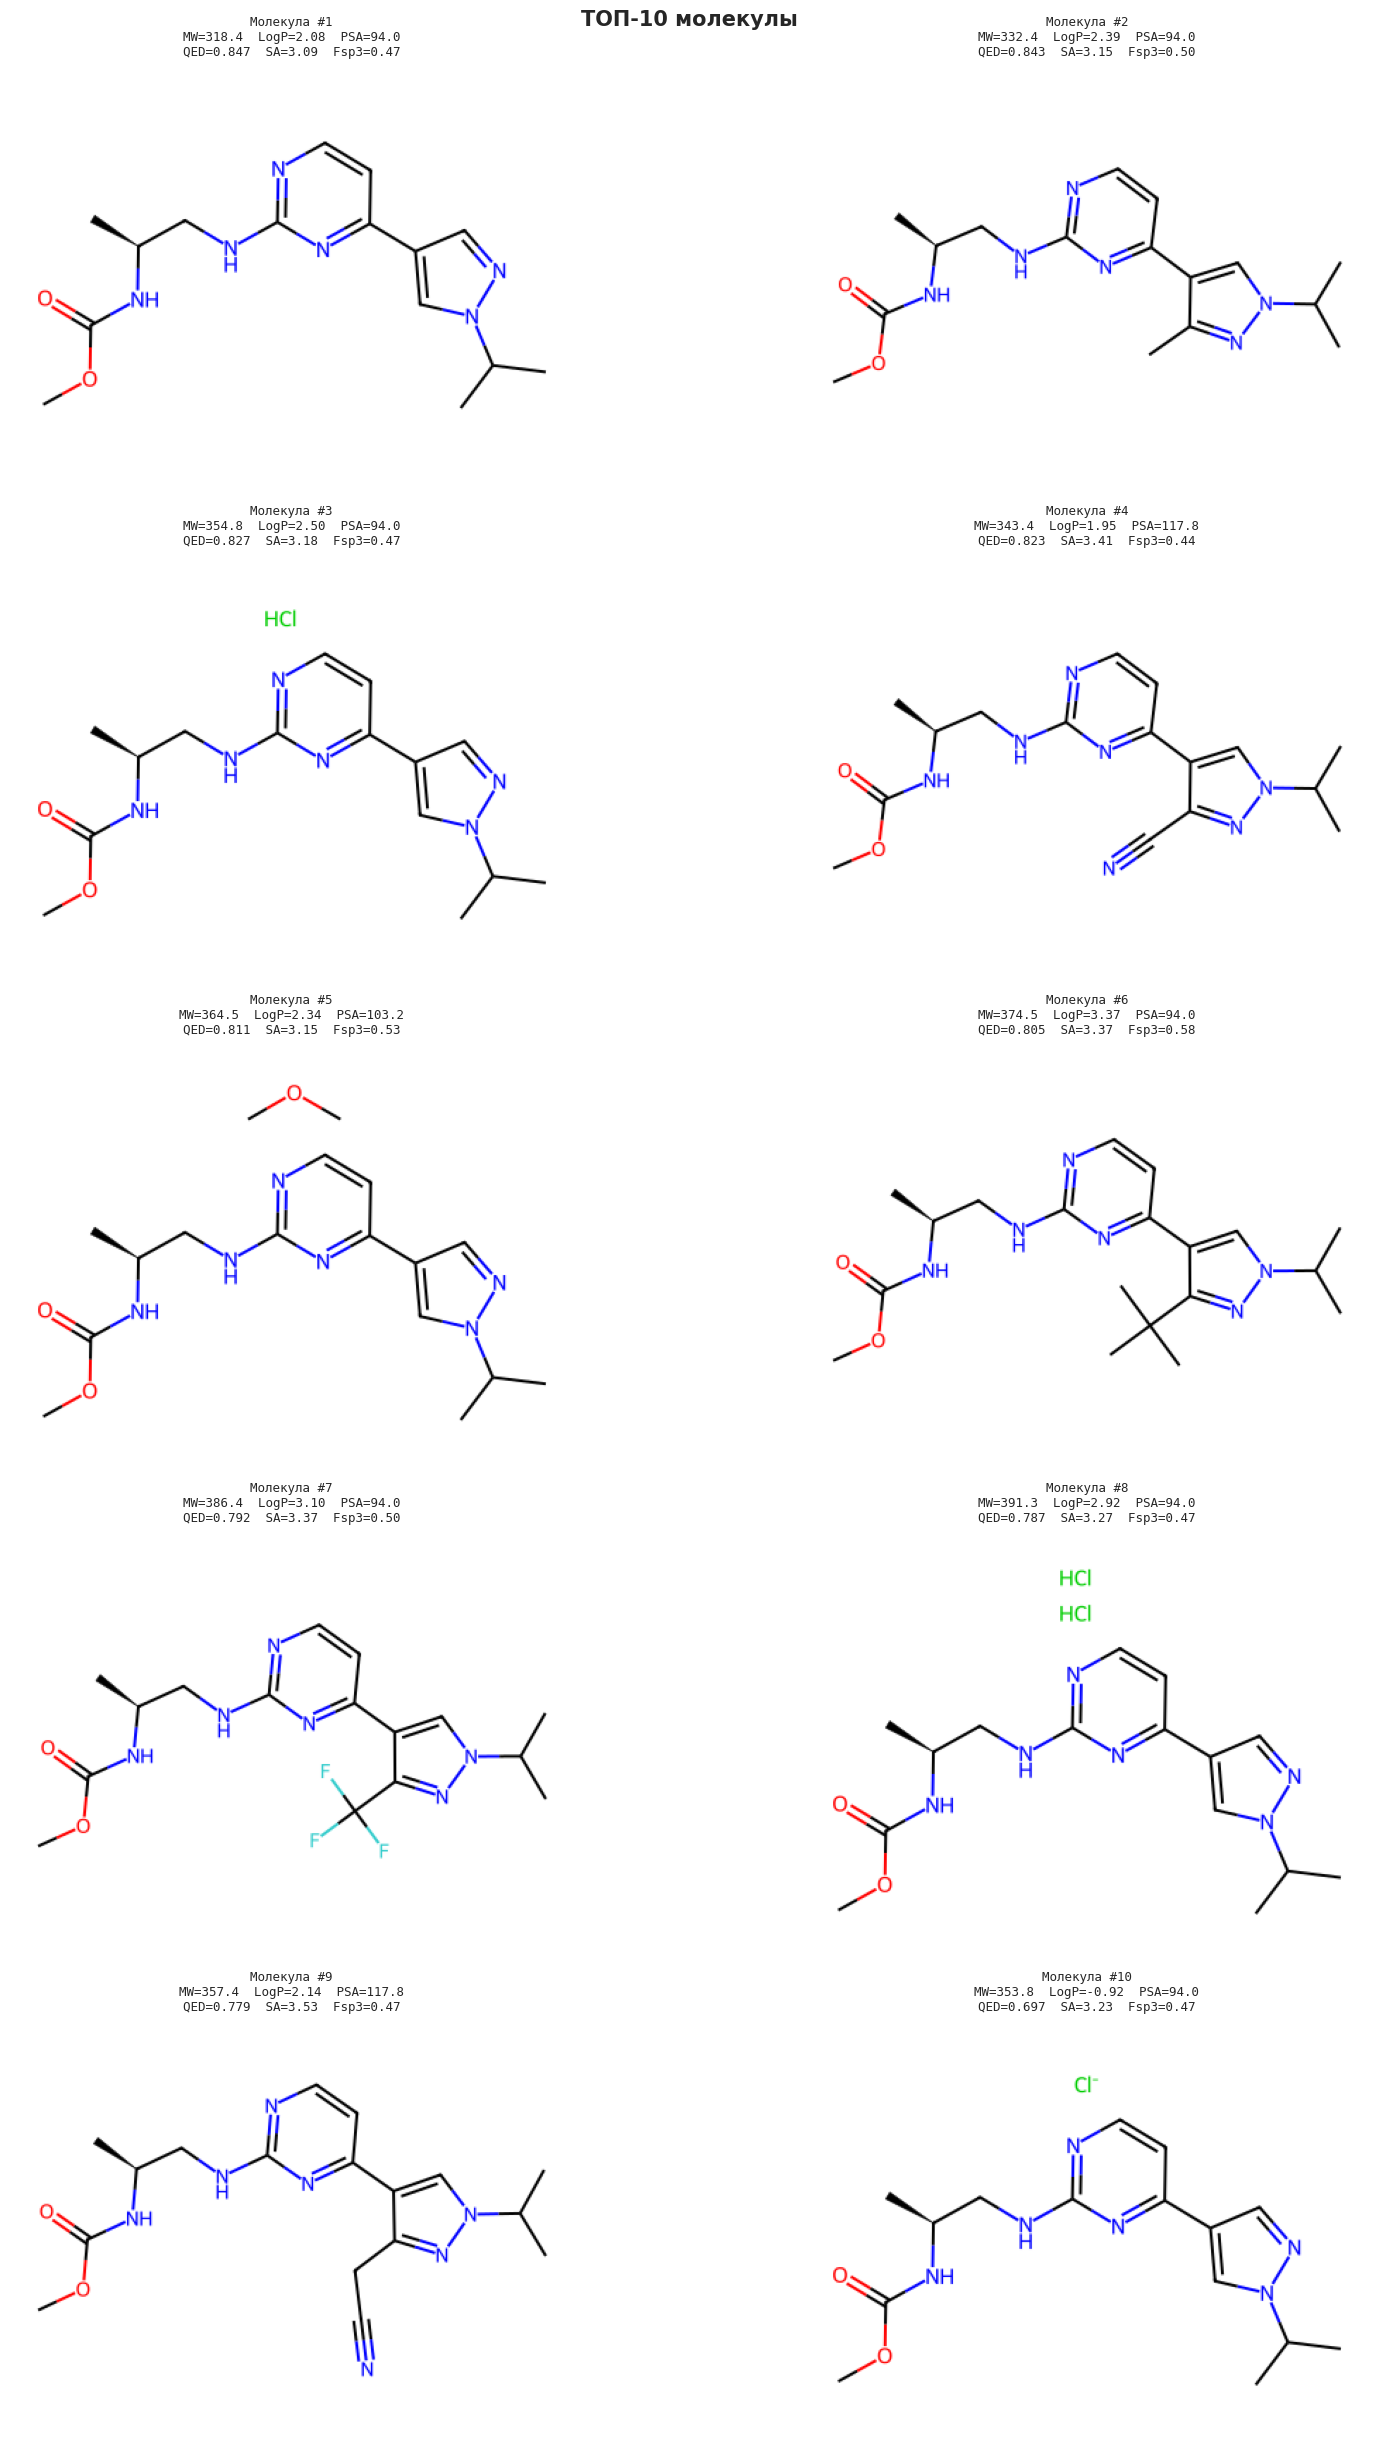

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(18, 25))
fig.suptitle('ТОП-10 молекулы', fontsize=15, fontweight='bold')

axes_flat = axes.flatten()

for idx, (_, row) in enumerate(top10.iterrows()):
    drawer = rdMolDraw2D.MolDraw2DCairo(400, 300)
    drawer.DrawMolecule(row['mol'])
    drawer.FinishDrawing()
    img = PILImage.open(io.BytesIO(drawer.GetDrawingText()))

    axes_flat[idx].imshow(img)
    axes_flat[idx].axis('off')
    axes_flat[idx].set_title(
        f'Молекула #{idx+1}\n'
        f'MW={row["MW"]:.1f}  LogP={row["LogP"]:.2f}  PSA={row["PSA"]:.1f}\n'
        f'QED={row["QED"]:.3f}  SA={row["SA_score"]:.2f}  Fsp3={row["Fsp3"]:.2f}',
        fontsize=9, fontfamily='monospace'
    )

plt.tight_layout()
plt.show()

Сравнение с оригинальной молекулой

In [40]:
# Загрузка энкорафениба из ChEMBL
molecule_api = new_client.molecule
mol = molecule_api.get('CHEMBL3301612')

smiles = mol['molecule_structures']['canonical_smiles']
props = mol['molecule_properties']

mw = float(props['mw_freebase'])
logp = float(props['alogp'])
psa = float(props['psa'])
hbd = int(props['hbd'])
hba = int(props['hba'])

rdmol = Chem.MolFromSmiles(smiles)
qed = rdQED.qed(rdmol)

encorafenib = pd.DataFrame([{
    'SMILES': smiles,
    'MW': mw,
    'LogP': logp,
    'PSA': psa,
    'HBD': hbd,
    'HBA': hba,
    'QED': round(qed, 3),
}])

encorafenib

,SMILES,MW,LogP,PSA,HBD,HBA,QED
0,COC(=O)N[C@@H](C)CNc1nccc(-c2cn(C(C)C)nc2-c2cc...,540.02,3.91,140.13,3,9,0.372


In [41]:
metrics = ['MW', 'LogP', 'PSA', 'HBD', 'HBA', 'QED']

stats = top10[metrics].agg(['mean', 'min', 'max', 'std']).round(2)
stats.loc['encorafenib'] = encorafenib[metrics].iloc[0].round(2)
print(stats)

                 MW  LogP     PSA  HBD   HBA   QED
mean         357.69  2.19   99.68  2.0  6.30  0.80
min          318.40 -0.92   94.00  2.0  6.00  0.70
max          391.30  3.37  117.80  2.0  7.00  0.85
std           22.84  1.19    9.97  0.0  0.48  0.04
encorafenib  540.02  3.91  140.13  3.0  9.00  0.37


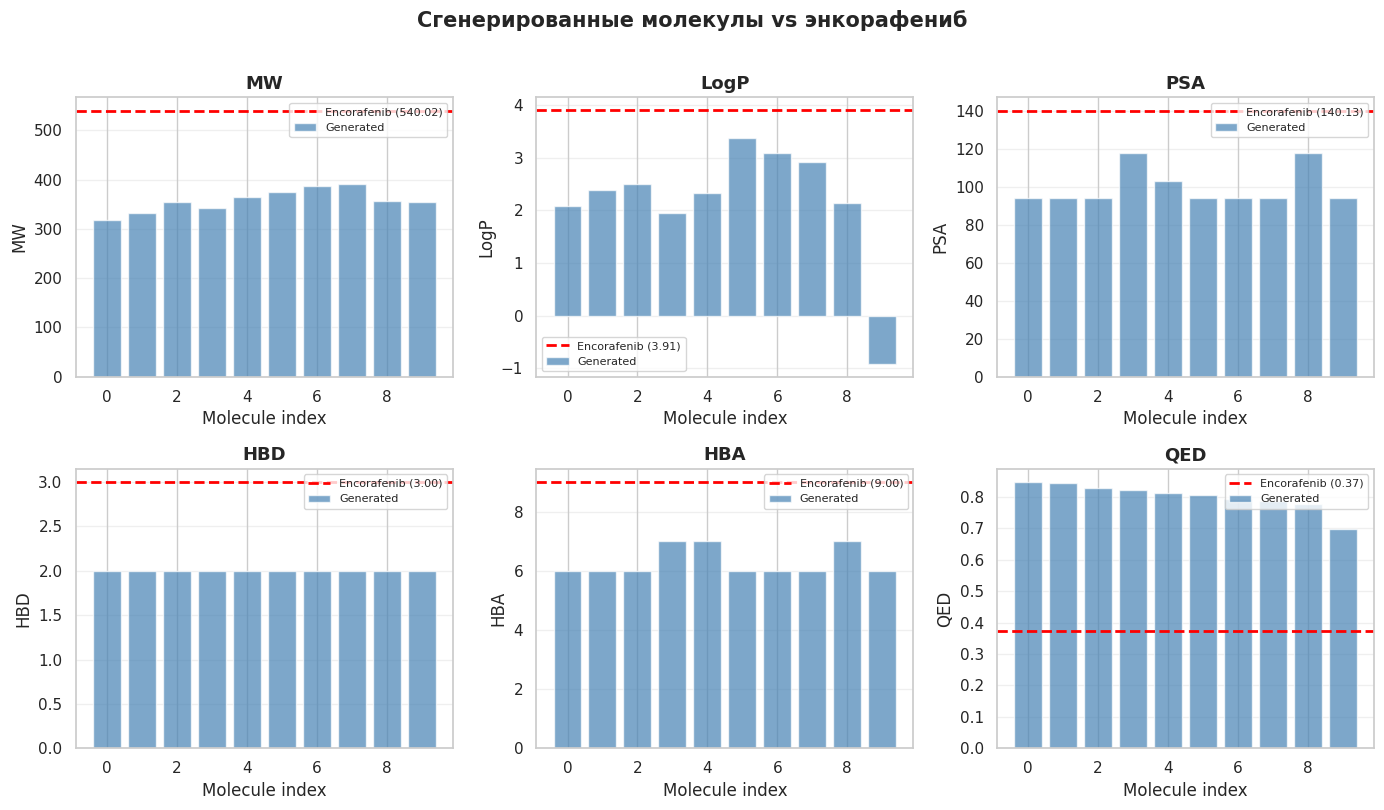

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    values = top10[metric].dropna()
    ref = encorafenib[metric].iloc[0]

    ax.bar(range(len(values)), values, color='steelblue', alpha=0.7, label='Generated')
    ax.axhline(ref, color='red', linewidth=2, linestyle='--', label=f'Encorafenib ({ref:.2f})')

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel('Molecule index')
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Сгенерированные молекулы vs энкорафениб', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Основные различия в физико-химических свойствах:

* Молекулярная масса (MW) - Все сгенерированные молекулы значительно легче энкорафениба

* Липофильность (LogP) - Большинство молекул менее липофильны, чем энкорафениб, что может улучшить их растворимость и фармакокинетические свойства

* Полярная площадь поверхности (PSA) - Сгенерированные молекулы имеют меньшую PSA по сравнению с энкорафенибом

* Водородные связи:
   - HBD: все молекулы имеют 2 донора водородных связей против 3 у энкорафениба
   - HBA: 6-7 акцепторов против 9 у энкорафениба

Ключевое преимущество: Все сгенерированные молекулы демонстрируют лучшие показатели QED (0.7-0.85) по сравнению с энкорафенибом (0.37), что указывает на их более высокую пригодность в качестве лекарственных кандидатов


Общий вывод

Сгенерированные молекулы представляют собой более оптимизированные структуры с улучшенными drug-like свойствами: они легче, менее полярны, имеют лучшее соответствие правилам лекарство-подобности и потенциально могут обладать улучшенной биодоступностью и фармакокинетикой по сравнению с энкорафенибом.